<a href="https://colab.research.google.com/github/zenku663-svg/heartdisease-ml-pluto-academy/blob/main/HeartDisease_ML_Project02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('heart.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
print(df.describe())
print("\nTarget value counts:")
print(df['target'].value_counts())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

In [3]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (1025, 13)
Target shape: (1025,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 820
Testing samples: 205


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3: KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [6]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, knn_pred)],
    'Precision': [precision_score(y_test, lr_pred),
                  precision_score(y_test, rf_pred),
                  precision_score(y_test, knn_pred)],
    'Recall':    [recall_score(y_test, lr_pred),
                  recall_score(y_test, rf_pred),
                  recall_score(y_test, knn_pred)],
    'F1 Score':  [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, knn_pred)]
})

results = results.round(3)
print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.795      0.756   0.874     0.811
1        Random Forest     0.985      1.000   0.971     0.985
2                  KNN     0.732      0.731   0.738     0.734


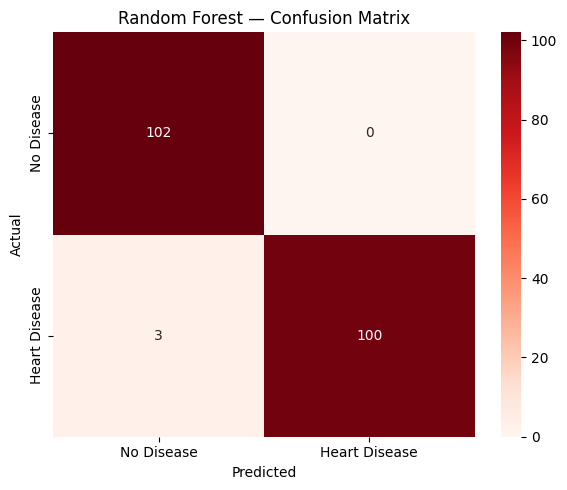

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [8]:
print("""
CONCLUSION — Heart Disease ML Project
======================================
1. We trained 3 ML models: Logistic Regression, Random Forest, and KNN
2. Random Forest performed best with 98.5% accuracy and 1.0 precision
3. Logistic Regression scored 79.5% accuracy — decent but not the best
4. KNN scored the lowest at 73.2% accuracy — not suitable for this dataset
5. Random Forest is recommended for heart disease prediction due to its
   ability to handle complex patterns across 13 medical features
""")


CONCLUSION — Heart Disease ML Project
1. We trained 3 ML models: Logistic Regression, Random Forest, and KNN
2. Random Forest performed best with 98.5% accuracy and 1.0 precision
3. Logistic Regression scored 79.5% accuracy — decent but not the best
4. KNN scored the lowest at 73.2% accuracy — not suitable for this dataset
5. Random Forest is recommended for heart disease prediction due to its
   ability to handle complex patterns across 13 medical features

